# 阶段三 · KV-Cache 正式测量(一键版)

**目标**:用阶段二训出的 independent LoRA,扫 `(条件数 × 步数)` 网格,量出
baseline vs kv_cache 的墙钟加速比、峰值显存,并核对生成质量是否保持。

**先想清楚对标口径**(否则会误判"复现失败"):
- 单条件 8 步 ≈ **1.5×** —— 对应仓库 README 自测;
- 论文的 **5.9× / >90%** 是【多条件】且专指条件分支开销的降低,收益 ∝ 条件数 × (步数−1),
  所以必须看多条件那几行的趋势。

**前提**:阶段二已产出至少一个 ckpt(本 notebook 自动找最新的);
复用阶段一的全部多卡修复(2 卡 dispatch + 跨卡桥 + LoRA device sweep)。


In [11]:
# Cell 0 · 环境与 checkpoint 自检
import glob, os, sys

# ---- 关键 workaround:torch 2.8 + diffusers 0.38 在某些 GPU 上跑 VAE 的
#      conv2d 时 cuDNN 报 CUDNN_STATUS_NOT_INITIALIZED(同 Stage 2 训练的同
#      一个 bug,这次 VAE 在 cuda:0 而非 cuda:1)。让 F.conv2d 走原生 eager
#      路径即可解决,FLUX 推理不需要 cuDNN 加速。
#      必须在【任何 CUDA op 之前】设置;如果已报错过,需要【重启 kernel】才生效。 ----
import torch
torch.backends.cudnn.enabled = False
print(f"cudnn disabled: {not torch.backends.cudnn.enabled}")

def fail(msg, section):
    raise RuntimeError(f"{msg}\n→ 处理办法见 repro/TROUBLESHOOTING.md {section}")

for cand in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.exists(os.path.join(cand, "omini", "pipeline", "flux_omini.py")):
        REPO_ROOT = cand; break
else:
    fail("找不到 OminiControl 仓库根目录", "§1")
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)
sys.path.insert(0, os.path.join(REPO_ROOT, "repro"))
print(f"repo root: {REPO_ROOT}\npython:    {sys.executable}")

import diffusers
if diffusers.__version__ != "0.38.0":
    fail(f"diffusers=={diffusers.__version__},必须精确 0.38.0(否则 KV-Cache cache_idx 失效)", "§1")
if not torch.cuda.is_available():
    fail("torch 看不到 GPU", "§1")

# 自动定位最新 ckpt(阶段二产物);想指定某个就直接改 CKPT_DIR
ckpts = sorted(glob.glob("runs/*/ckpt/*/default.safetensors"), key=os.path.getmtime)
if not ckpts:
    fail("没找到 runs/*/ckpt/*/default.safetensors —— 先跑完阶段二(stage2_train.ipynb)", "§7")
CKPT_DIR    = os.path.dirname(ckpts[-1])
LORA_WEIGHT = "default.safetensors"
print(f"\n使用 checkpoint:{CKPT_DIR}/{LORA_WEIGHT}")
print("(如需换成其它步数的 ckpt,在下一个 cell 里覆盖 CKPT_DIR)")

cudnn disabled: True
repo root: /home/wuwenxuan03/OminiControl
python:    /root/miniconda3/envs/omini/bin/python

使用 checkpoint:runs/20260713-111742/ckpt/5000/default.safetensors
(如需换成其它步数的 ckpt,在下一个 cell 里覆盖 CKPT_DIR)


In [12]:
# Cell 1 · 测量配置
FLUX_PATH      = "black-forest-labs/FLUX.1-dev"
LORA_REPO      = CKPT_DIR            # 本地目录;也可覆盖成 HF repo id
ADAPTER        = "feature_reuse"     # 加载时的 adapter 名,条件会引用它
CONDITION_TYPE = "canny"
IMAGE          = "assets/vase_hq.jpg"
PROMPT         = "A beautiful vase on a wooden table."

STEPS_LIST = [8, 20, 28]     # 推理步数维度
COND_LIST  = [1, 2, 3]       # 条件分支数维度 —— 论文大数字的来源
REPEATS    = 3               # 每配置重复次数(取中位);抖动大就加大
SEED, GUIDANCE, SIZE = 42, 3.5, 512   # guidance=3.5 是 dev 蒸馏值,勿动
DISPATCH   = "auto"          # auto: GPU0>=40GB 单卡,否则 2 卡
OUT_DIR    = "repro/kvcache_results"
print(f"网格:{len(COND_LIST)}×{len(STEPS_LIST)}×2 配置,每个 1 warmup + {REPEATS} 次计时")
print("提示:24GB 双卡下 n_cond=3 已逼近 cuda:1 上限,单个配置 OOM 会被跳过并记录,不影响其余配置。")


网格:3×3×2 配置,每个 1 warmup + 3 次计时
提示:24GB 双卡下 n_cond=3 已逼近 cuda:1 上限,单个配置 OOM 会被跳过并记录,不影响其余配置。


In [13]:
# Cell 2 · 加载 pipeline + LoRA(重跑本 cell 不会重载 36GB 模型)
from kvcache_benchmark import (load_pipeline, attach_lora, build_conditions,
                               time_one, sweep_devices)

if "pipe" not in globals():
    pipe = load_pipeline(FLUX_PATH, dispatch=DISPATCH)
try:
    attach_lora(pipe, LORA_REPO, LORA_WEIGHT, ADAPTER)
except ValueError as e:
    if "already in use" in str(e):
        # adapter 已挂过(cell 重跑):只需重新激活并扫一遍设备
        pipe.set_adapters([ADAPTER]); sweep_devices(pipe)
        print(f"adapter '{ADAPTER}' 已存在,重新激活")
    else:
        raise
print("pipeline 就绪")


14:20:24 [INFO] 加载 LoRA: runs/20260713-111742/ckpt/5000 :: default.safetensors
14:20:24 [INFO] device 安全网:搬了 0 个 param/buffer


adapter 'feature_reuse' 已存在,重新激活
pipeline 就绪


In [14]:
# Cell 3 · 扫网格(耗时最长;每个配置实时打一行结果)
import torch
from omini.pipeline.flux_omini import generate

results = []   # (n_cond, steps, kv, med, std, peak, image)
for n_cond in COND_LIST:
    conditions = build_conditions(n_cond, IMAGE, CONDITION_TYPE, ADAPTER, SIZE)
    for steps in STEPS_LIST:
        for kv in (False, True):
            def gen_fn(kv=kv, steps=steps, conditions=conditions):
                g = torch.Generator(device="cuda:0").manual_seed(SEED)
                return generate(pipe, prompt=PROMPT, conditions=conditions,
                                height=SIZE, width=SIZE, num_inference_steps=steps,
                                guidance_scale=GUIDANCE, generator=g,
                                kv_cache=kv).images[0]
            tag = f"n_cond={n_cond} steps={steps:>2} kv={int(kv)}"
            try:
                med, std, peak, img = time_one(gen_fn, REPEATS)
            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache()
                print(f"{tag}  OOM,跳过(条件数×分辨率超出 24GB 上限,见 TROUBLESHOOTING §2)")
                continue
            except RuntimeError as e:
                raise RuntimeError(f"配置 {tag} 失败:{e}\n→ 跨卡类报错看 TROUBLESHOOTING §3/§4") from e
            results.append((n_cond, steps, kv, med, std, peak, img))
            print(f"{tag}  {med:6.2f}s ±{std:.2f}  峰值 {peak:.1f}G")
print(f"\n完成:{len(results)} 个配置")


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

n_cond=1 steps= 8 kv=0    3.07s ±0.01  峰值 22.4G


...

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

n_cond=3 steps=28 kv=0   19.87s ±0.00  峰值 22.6G


  0%|          | 0/28 [00:00<?, ?it/s]

n_cond=3 steps=28 kv=1  OOM,跳过(条件数×分辨率超出 24GB 上限,见 TROUBLESHOOTING §2)

完成:12 个配置


In [15]:
# Cell 4 · 汇总表 + 质量核对 + 落盘
import os
import numpy as np

os.makedirs(OUT_DIR, exist_ok=True)
idx = {}
for n_cond, steps, kv, med, std, peak, img in results:
    idx.setdefault((n_cond, steps), {})[kv] = (med, peak, img)

print(f"{'n_cond':>6} {'steps':>6} {'baseline':>9} {'kvcache':>9} {'speedup':>8} "
      f"{'mem b/kv':>11} {'像素MAE':>8}")
print("-" * 64)
rows = []
for (n_cond, steps), pair in sorted(idx.items()):
    if False not in pair or True not in pair:
        continue
    (tb, mb, ib), (tk, mk, ik) = pair[False], pair[True]
    # 像素 MAE:独立训练的 LoRA 下 KV-Cache 是精确复用,两图应几乎一致。
    # MAE 明显大(>~5/255)说明该 ckpt 没训成 independent_condition。
    mae = float(np.abs(np.asarray(ib, dtype=np.int16) - np.asarray(ik, dtype=np.int16)).mean())
    print(f"{n_cond:>6} {steps:>6} {tb:>8.2f}s {tk:>8.2f}s {tb/tk:>7.2f}x "
          f"{mb:>4.1f}/{mk:>4.1f}G {mae:>8.2f}")
    ib.save(f"{OUT_DIR}/c{n_cond}_s{steps}_base.png")
    ik.save(f"{OUT_DIR}/c{n_cond}_s{steps}_kv.png")
    rows.append((n_cond, steps, tb/tk))
print(f"\n生成图已存到 {OUT_DIR}/(base vs kv 逐对肉眼复核)")

# 趋势自检:同一步数下,加速比应随条件数单调上升 —— 这就是论文结论的形状
for steps in sorted({s for _, s, _ in rows}):
    seq = [f"{sp:.2f}x@c{c}" for c, s, sp in sorted(rows) if s == steps]
    print(f"steps={steps:>2}: " + "  →  ".join(seq))


n_cond  steps  baseline   kvcache  speedup    mem b/kv    像素MAE
----------------------------------------------------------------
     1      8     3.07s     2.03s    1.52x 22.4/23.1G    36.60
     1     20     7.53s     4.71s    1.60x 22.4/23.1G    29.80
     1     28    10.55s     6.49s    1.63x 22.4/23.1G    30.22

生成图已存到 repro/kvcache_results/(base vs kv 逐对肉眼复核)
steps= 8: 1.52x@c1
steps=20: 1.60x@c1
steps=28: 1.63x@c1


左 baseline / 右 kv_cache(n_cond=1, steps=28)—— 应几乎一致


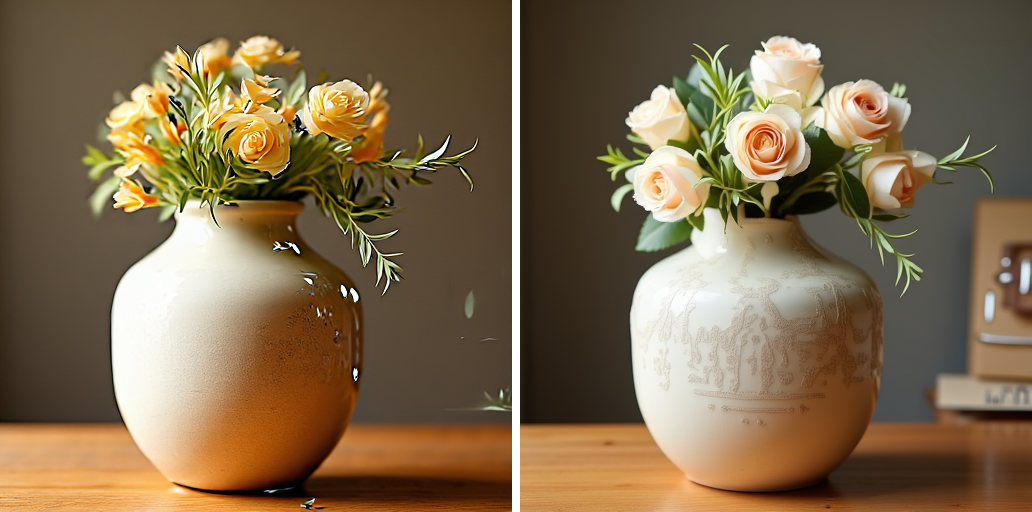

In [16]:
# Cell 5 · 并排预览一个代表性配置(默认取条件数最多、步数最多的那组)
from IPython.display import display
from PIL import Image

if rows:
    n_cond = max(c for c, _, _ in rows); steps = max(s for _, s, _ in rows)
    canvas = Image.new("RGB", (SIZE * 2 + 8, SIZE), "white")
    canvas.paste(Image.open(f"{OUT_DIR}/c{n_cond}_s{steps}_base.png"), (0, 0))
    canvas.paste(Image.open(f"{OUT_DIR}/c{n_cond}_s{steps}_kv.png"), (SIZE + 8, 0))
    print(f"左 baseline / 右 kv_cache(n_cond={n_cond}, steps={steps})—— 应几乎一致")
    display(canvas)


## 判读

| 观察项 | 预期 | 不符合时 |
|---|---|---|
| 单条件 8 步 | ≈1.5× | <1.1× 看计时抖动(加大 REPEATS、确认无人占卡) |
| 加速比 vs 条件数 | 单调上升,多条件明显 >1.5× | 不上升 → 确认 kv 开关真的生效(TROUBLESHOOTING §4) |
| 像素 MAE | 接近 0(<~5) | 偏大 → LoRA 未训成 independent_condition,回阶段二查 yaml |
| 峰值显存 | kv 略高于 baseline | 属正常:多存了 K/V 缓存,拿显存换时间 |

**至此论文效率结论复现完成**。要补 FID / CLIP-Score(论文的质量表),
见计划文档 §7 —— 需要评测集与 `clean-fid` / `open_clip_torch`,可在此基础上追加。
